In [1]:
import fft_poisson_solver_opt
import fft_poisson_solver
import numpy as np
from matplotlib import pyplot as plt
import imageio
from scipy import sparse
import os
import tvl1_poisson_solver
import tvl1_color_fix
import torch

pyFFTW will use up to 64 threads.


In [2]:
file_name = "test_shift"
folder_name = "../results/paper_rgb/"
result_dir = "../results/paper_rgb/"
os.makedirs(result_dir, exist_ok=True)

In [3]:
# clip to matrix range [-1, 1]
# sparse_matrix_x.data = np.clip(sparse_matrix_x.data, -1, 1)
# sparse_matrix_y.data = np.clip(sparse_matrix_y.data, -1, 1)
sparse_matrix_x_b = np.load(folder_name+'r/image_registration/'+file_name+'_x.npy')
sparse_matrix_y_b = np.load(folder_name+'r/image_registration/'+file_name+'_y_warp.npy')
sparse_matrix_x_g = np.load(folder_name+'g/image_registration/'+file_name+'_x.npy')
sparse_matrix_y_g = np.load(folder_name+'g/image_registration/'+file_name+'_y_warp.npy')
sparse_matrix_x_r = np.load(folder_name+'b/image_registration/'+file_name+'_x.npy')
sparse_matrix_y_r = np.load(folder_name+'b/image_registration/'+file_name+'_y_warp.npy')
sparse_matrix_x = np.stack([sparse_matrix_x_r, sparse_matrix_x_g, sparse_matrix_x_b], axis=2)
sparse_matrix_y = np.stack([sparse_matrix_y_r, sparse_matrix_y_g, sparse_matrix_y_b], axis=2)
# sparse_matrix_x = sparse_matrix_x[:, 500: -500]
# sparse_matrix_y = sparse_matrix_y[:, 500: -500]
print(sparse_matrix_x.max())
print(sparse_matrix_x.min())
print(sparse_matrix_y.max())
print(sparse_matrix_y.min())
print(np.abs(sparse_matrix_x).max())
print(np.abs(sparse_matrix_y).max())
print(np.abs(sparse_matrix_x).min())
print(np.abs(sparse_matrix_y).min())

print(sparse_matrix_x.shape)
print(sparse_matrix_y.shape)

1.0
-1.0
1.0
-1.0


1.0
1.0


0.0
0.0
(4000, 4000, 3)
(4000, 4000, 3)


--- Phase 1: Gradient Transformation ---


--- Phase 2: Solving Independent Channels ---
Reconstructing Luminance (lambda=1.0)...
Starting Strict Neumann TV-L1...


Iter 0, Diff: 7.81e-03, Loss: 1.74e-01


Iter 100, Diff: 8.34e-03, Loss: 8.31e-02


Iter 200, Diff: 3.47e-03, Loss: 7.01e-02


...

Iter 3800, Diff: 7.36e-05, Loss_c1: 0.051706, Loss_c2: 0.049942


Iter 3900, Diff: 7.16e-05, Loss_c1: 0.051704, Loss_c2: 0.049939


Analyzing dominant hues (Upper Hemisphere Only) with K=8...
Found 2 distinct axes (Hemisphere Folded).
  Axis 1: (0.70, 0.71)
  Axis 2: (0.25, 0.97)
Plotting gradient scatter...


Scatter plot saved to ../results/debug/gradient_distribution_reconstructed.png


--- Phase 3: Inverse Transformation ---
Shape: (4000, 4000, 3)
Min: -9.659236907958984
Max: 4.012818813323975


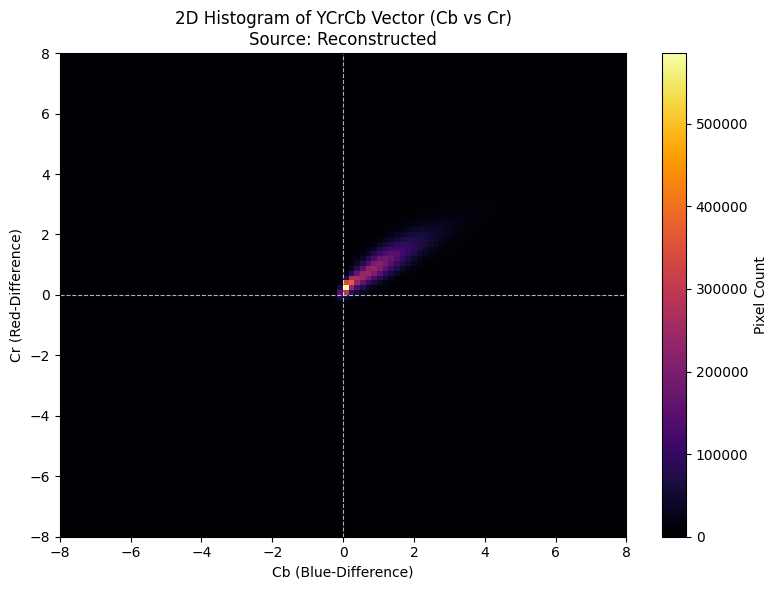

In [4]:
grad_x_torch = torch.from_numpy(sparse_matrix_x)
grad_y_torch = torch.from_numpy(sparse_matrix_y)
with torch.no_grad(): # Disable autograd to save huge memory and speed up
    reconstructed_gpu, gray_scale_image = tvl1_color_fix.reconstruct_color_consistent(
    grad_x_torch, grad_y_torch,
    lambda_lum=1.0,    
    lambda_chrom=1.0,  
    lambda_sparsity=0.0,
    n_iters_lum=4000,
    n_iters_chrom=4000,
    adaptive_iters=2000,
    device='cuda:1'
)
event_reconstructed = reconstructed_gpu
print(f"Shape: {event_reconstructed.shape}")
print(f"Min: {np.min(event_reconstructed)}")
print(f"Max: {np.max(event_reconstructed)}")

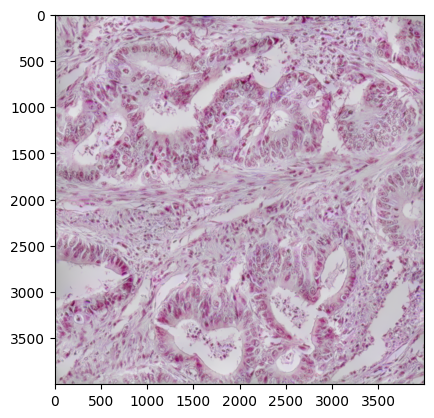

In [5]:
disp = reconstructed_gpu - reconstructed_gpu.min()
disp = disp / (disp.max() + 1e-8)
# disp = reconstructed_gpu
plt.imshow(disp)
plt.show()

In [6]:
event_reconstructed = reconstructed_gpu
# Normalize to [0,1] range
event_reconstructed = (event_reconstructed - np.min(event_reconstructed)) / (np.max(event_reconstructed) - np.min(event_reconstructed))
# # Exponentiate the reconstructed values to linearize the image
event_reconstructed = np.exp(event_reconstructed)
# # Apply gamma correction with gamma=2.2
event_reconstructed = event_reconstructed ** (1/2.2)
event_reconstructed = (event_reconstructed - np.min(event_reconstructed)) / (np.max(event_reconstructed) - np.min(event_reconstructed))
# np.save(result_dir+file_name+"_reconstructed.npy", event_reconstructed)
plt.imsave(result_dir+file_name+"_reconstructed_test.png", (event_reconstructed * 255.0).astype(np.uint8))

# Auto HDR based on histogram analysis
hist, bins = np.histogram(event_reconstructed.flatten(), bins=65536)
cumsum = np.cumsum(hist)
cumsum = cumsum / cumsum[-1] # Normalize to [0,1]

# Find points for histogram equalization 
low_percentile = 15/65535  # Bottom 0.000015%
high_percentile = 65000/65535 # Top 0.000015%

# Find the intensity values at these percentiles
low_value = bins[np.where(cumsum > low_percentile)[0][0]]
high_value = bins[np.where(cumsum > high_percentile)[0][0]]

# Apply exposure adjustment based on histogram analysis
exposure_factor = 1.0 / (high_value - low_value)
event_reconstructed_hdr = (event_reconstructed - low_value) * exposure_factor

# Clip to ensure values stay in [0,1] range after exposure increase
event_reconstructed_hdr = np.clip(event_reconstructed_hdr, 0, 1)
# np.save(result_dir+file_name+"_reconstructed.npy", event_reconstructed_hdr)
# Convert to 0-255 range
event_reconstructed_hdr = (event_reconstructed_hdr * 255).astype(np.uint8)
# Save using imageio

# imageio.imwrite(result_dir+file_name+"_reconstructed_downsampled_8x.png", event_reconstructed[::8, ::8])
plt.imsave(result_dir+file_name+"_reconstructed_hdr_test.png", event_reconstructed_hdr)


In [7]:
event_reconstructed = gray_scale_image
# Normalize to [0,1] range
event_reconstructed = (event_reconstructed - np.min(event_reconstructed)) / (np.max(event_reconstructed) - np.min(event_reconstructed))
# # Exponentiate the reconstructed values to linearize the image
event_reconstructed = np.exp(event_reconstructed)
# # Apply gamma correction with gamma=2.2
event_reconstructed = event_reconstructed ** (1/2.2)
event_reconstructed = (event_reconstructed - np.min(event_reconstructed)) / (np.max(event_reconstructed) - np.min(event_reconstructed))
# np.save(result_dir+file_name+"_reconstructed.npy", event_reconstructed)
plt.imsave(result_dir+file_name+"_reconstructed_test_grayscale.png", (event_reconstructed * 255.0).astype(np.uint8), cmap="gray")

# Auto HDR based on histogram analysis
hist, bins = np.histogram(event_reconstructed.flatten(), bins=65536)
cumsum = np.cumsum(hist)
cumsum = cumsum / cumsum[-1] # Normalize to [0,1]

# Find points for histogram equalization 
low_percentile = 200/65535  # Bottom 0.000015%
high_percentile = 65500/65535 # Top 0.000015%

# Find the intensity values at these percentiles
low_value = bins[np.where(cumsum > low_percentile)[0][0]]
high_value = bins[np.where(cumsum > high_percentile)[0][0]]

# Apply exposure adjustment based on histogram analysis
exposure_factor = 1.0 / (high_value - low_value)
event_reconstructed_hdr = (event_reconstructed - low_value) * exposure_factor

# Clip to ensure values stay in [0,1] range after exposure increase
event_reconstructed_hdr = np.clip(event_reconstructed_hdr, 0, 1)
# np.save(result_dir+file_name+"_reconstructed.npy", event_reconstructed_hdr)
# Convert to 0-255 range
event_reconstructed_hdr = (event_reconstructed_hdr * 255).astype(np.uint8)
# Save using imageio

# imageio.imwrite(result_dir+file_name+"_reconstructed_downsampled_8x.png", event_reconstructed[::8, ::8])
plt.imsave(result_dir+file_name+"_reconstructed_hdr_test_grayscale.png", event_reconstructed_hdr, cmap="gray")

In [8]:
import torch
import numpy as np
import imageio
from tqdm import tqdm

# Check if GPU is available
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def auto_normalize_vectorized(patch_batch):
    """
    对一个 batch 的 patch 做归一化（支持 RGB，多通道）。
    patch_batch: [B, C, H, W]
    归一化方式：每个 patch 内只把最大值拉到 1，不做减去最小值的操作；
    small_range_mask 仍然把低动态范围的 patch 置为白色。
    """
    B, C, H, W = patch_batch.shape
    flat_patches = patch_batch.view(B, -1)  # [B, C*H*W]

    # 1. 每个 patch 的全局 min/max（跨通道）
    min_vals = flat_patches.min(dim=1, keepdim=True).values  # [B,1]
    max_vals = flat_patches.max(dim=1, keepdim=True).values  # [B,1]
    ranges = max_vals - min_vals

    # small_range_mask：动态范围太小的 patch 直接变为白色
    small_range_mask = (ranges < 0.15)  # [B,1]

    # 避免除 0
    max_vals_safe = max_vals + 1e-8  # [B,1]

    # 2. 只用 max 做缩放：x -> x / max
    scale = (1.0 / max_vals_safe).view(B, 1, 1, 1)  # reshape 方便广播
    normalized = patch_batch * scale  # [B, C, H, W]

    # 3. small range -> 直接输出 1.0（白色）
    mask_4d = small_range_mask.view(B, 1, 1, 1)  # [B,1,1,1]
    normalized = torch.where(mask_4d, torch.ones_like(normalized), normalized)

    return normalized

# --- Main Execution ---

# 1. Setup Data on GPU
event_reconstructed = (reconstructed_gpu-reconstructed_gpu.min())/(reconstructed_gpu.max()-reconstructed_gpu.min())
patch_size = 200
step = 2
h, w, c = event_reconstructed.shape  # 现在是 RGB，形状 [H, W, 3]
pad_amt = patch_size // 2

# 转为 [C, H, W]，并归一化到 [0, 1]
img_tensor = torch.from_numpy(event_reconstructed.astype(np.float32)).to(device)  # [H, W, 3]
img_tensor = img_tensor.permute(2, 0, 1)  # [3, H, W]

# 在 GPU 上做 padding（只 pad 空间维度）
img_padded = torch.nn.functional.pad(
    img_tensor, (pad_amt, pad_amt, pad_amt, pad_amt), mode='constant', value=0
)  # [3, H+2p, W+2p]

# Accumulation Buffers on GPU
output_accumulator = torch.zeros_like(img_padded)   # [3, H+2p, W+2p]
weight_accumulator = torch.zeros_like(img_padded)   # [3, H+2p, W+2p]

# Pre-calculate coordinates
rows = list(range(0, h, step))
cols = list(range(0, w, step))
patch_coords = [(r, c) for r in rows for c in cols]

# 2. Process in Batches
batch_size = 1024  # 可根据显存调节

print(f"Total patches: {len(patch_coords)}")

# 用于权重累积，每个 patch 权重为 1
ones_patch = torch.ones((1, patch_size, patch_size), device=device)  # [1, H, W]，在通道上广播

for batch_start in tqdm(range(0, len(patch_coords), batch_size), desc="GPU Processing"):
    batch_end = min(batch_start + batch_size, len(patch_coords))
    current_coords = patch_coords[batch_start:batch_end]

    if not current_coords:
        continue

    # 提取 patch：得到 [B, 3, patch_size, patch_size]
    batch_patches = torch.stack([
        img_padded[:, r:r+patch_size, c:c+patch_size]
        for r, c in current_coords
    ])

    # 只做归一化 + small_range_mask
    processed_batch = auto_normalize_vectorized(batch_patches)  # [B, 3, H, W]

    # 累积回主图
    for idx, (r, c) in enumerate(current_coords):
        output_accumulator[:, r:r+patch_size, c:c+patch_size] += processed_batch[idx]
        weight_accumulator[:, r:r+patch_size, c:c+patch_size] += ones_patch

# 3. Normalize and Save
# 避免除 0
weight_accumulator[weight_accumulator == 0] = 1.0
final_output = output_accumulator / weight_accumulator  # [3, H+2p, W+2p]

# Crop padding
final_output = final_output[:, pad_amt:pad_amt+h, pad_amt:pad_amt+w]  # [3, H, W]

# Clip and Convert
final_output = torch.clamp(final_output, 0, 1)
final_output = final_output.permute(1, 2, 0)  # 回到 [H, W, 3]
final_output = torch.exp(final_output)
final_output = final_output ** (1/2.2)
final_output_min = final_output.min()
final_output_max = final_output.max()
# print(final_output_min, final_output_max)
# final_output = final_output-(final_output_max-1.0)
# final_output_min = final_output.min()
# final_output_max = final_output.max()
final_output = (final_output-final_output_min)/(final_output_max-final_output_min)
# print(final_output.min(), final_output.max())
# final_output = (final_output*(1.0-0.2))+0.2
# print(final_output.min(), final_output.max())
result_uint8 = (final_output * 255).byte().cpu().numpy()

imageio.imwrite(result_dir + file_name + "_reconstructed_auto_hdr_optimized.png", result_uint8)

Using device: cuda:1


Total patches: 4000000


GPU Processing:   0%|          | 0/3907 [00:00<?, ?it/s]

GPU Processing:   0%|          | 4/3907 [00:00<02:02, 31.94it/s]

GPU Processing:   0%|          | 8/3907 [00:00<01:59, 32.52it/s]

...

GPU Processing: 100%|█████████▉| 3892/3907 [01:59<00:00, 32.70it/s]

GPU Processing: 100%|█████████▉| 3896/3907 [01:59<00:00, 32.72it/s]

GPU Processing: 100%|█████████▉| 3900/3907 [01:59<00:00, 32.69it/s]

GPU Processing: 100%|█████████▉| 3904/3907 [01:59<00:00, 32.64it/s]

GPU Processing: 100%|██████████| 3907/3907 [02:00<00:00, 32.55it/s]